<a href="https://colab.research.google.com/github/deepkkumar07/Customer_Segmentation_Case_study/blob/main/Copy_of_Customer_Segmentation_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer segmentation** is the process of dividing a company’s target market into smaller, distinct groups of customers who share similar characteristics, behaviors, or needs.

We need **customer segmentation** because customers are not identical, and a single strategy will not appeal to everyone. If a business treats every customer the exact same way, it wastes money on irrelevant marketing and misses out on sales.


# Why Customer segmentation is essential for any business:
* **Smarter Marketing Spend:** Instead of wasting money broadcasting a generic ad to millions of people, you can target specific groups. For example, a clothing brand can show winter coats to customers in cold regions and swimwear to customers in tropical areas.

* **Higher Conversion Rates:** People respond better to messages that feel personal. When you pitch the right product to the right group based on their specific needs, they are much more likely to buy.

* **Better Product Development:** By understanding what different segments want, you can design products that solve their exact problems. A tech company might build a simple, budget version of their software for students and a complex, premium version for large corporations.

* **Improved Customer Retention:** You can identify "at-risk" customers (those who haven't bought anything in months) and send them a special discount to win them back before they switch to a competitor.

#Type of Market Segmentation
* Demographic
* Psychological
* Needs based
* Behavioural
* Transactional

#Problem Description:
In this case study, the task is to identify major customer segments on a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.


#Data Description:
Attribute Information:

* InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
* StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
* Description: Product (item) name. Nominal.
* Quantity: The quantities of each product (item) per transaction. Numeric.
* InvoiceDate: Invoice Date and time. Numeric, the day and time when each transaction was generated.
* UnitPrice: Unit price. Numeric, Product price per unit in sterling.
* CustomerID: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
* Country: Country name. Nominal, the name of the country where each customer resides.

# **Import the libraries and the dataset to understand the variable/features present**

In [197]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
%matplotlib inline

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [199]:
# loading dataset
customer_data = pd.read_csv('/content/drive/MyDrive/machine learning/Online Retail.csv')

After loading the dataset and going through the dataset we can say this is a unsupervised Problem beacuse:
* There is no target variable .
* We have to do segemntation here.

In [200]:
#loading first 10 rows of dataset
customer_data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [201]:
customer_data.tail(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


In [202]:
#shape of dataset
customer_data.shape

(541909, 8)

In [203]:
customer_data.info()
# here customer id , invoice date , invoice number data types are wrong so we need to fix those columns before going ahead

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [204]:
customer_data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# **Handling Duplicates , missing , or wrong information in the dataset :**

In [205]:
# since we are getting -ve values in quantity column and quantity can't be negative
# so we will check how many values in quatiuty column are -ve and we will check if we can consider them as outlier ?
customer_data[customer_data['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


If  we go through the dataset description we can see :
* InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
* That means -ve value in quantity are actually returned orders and since In this case we are not focused on returned orders so we can ignore/remove them from our dataset.

In [206]:
# removing all the rows where quantity is newgative
customer_data = customer_data[customer_data['Quantity']>=0]

In [207]:
print(customer_data.shape)
customer_data.head(5)

(531285, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


# Duplicates

In [208]:
customer_data.duplicated().sum()

np.int64(5231)

In [209]:
customer_data[customer_data.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/10 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/10 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/10 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/10 11:49,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/11 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/11 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/11 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,12/9/11 11:34,2.10,14446.0,United Kingdom




*   There are 5231 duplicate record in dataset so we wil remove those records




In [210]:
# checking random values from above dataset if is there any suchg duplicate value or not
filtered_data = customer_data[(customer_data['InvoiceNo'] == '536409') & (customer_data['StockCode'] == '21866')]
filtered_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom


In [211]:
# droping the duplicated record from dataset
customer_data.drop_duplicates(inplace= True)

In [212]:
# checking iof duplicated records are treated or not.
customer_data[customer_data.duplicated()]
# after this line of code we can se all the duplicated records has been reomved successfully from dataset

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


# Handling Null values

In [213]:
customer_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,592
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,133322
Country,0



*   There are 592 null values in Description and 133322 record are null in customerID

In [214]:
# droping NA (null) values
customer_data.dropna(inplace = True)

In [215]:
customer_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


* We have successfuly removed all the rows with null values


In [216]:
customer_data.describe()

,Quantity,UnitPrice,CustomerID
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,15287.734822
std,181.588420,22.240725,1713.567773
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


* here min value for UnitPrice is 0 which do not have any predictive power so we can remove those rows

In [217]:
# checking if there is any value in unit price with 0 as values ?
customer_data = customer_data[customer_data['UnitPrice']>0]

In [218]:
customer_data[customer_data['UnitPrice']==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


* we have successfulu removed all rows from unit price where unit price was 0
* dataset is now cleaned

In [219]:
customer_data.shape

(392692, 8)

#**Feature Engineering(Creating New Features )**

**Feature Engineering** is a **Machine Learning** technique that leverage data to create new variables that are not present in the dataset. It can produce new feature for both **Supervised** and **Unsupervised** machine learning models with goal of simplifying and speeding up data transformtation while also enhancing models accuracy


In [220]:
customer_data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


In [221]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [222]:
#convert invoice date into date time format
customer_data['InvoiceDate'] = pd.to_datetime(customer_data['InvoiceDate'], format= '%m/%d/%y  %H:%M')

In [223]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


* Successfully changed the invoiceDate column from type Object to Datetime
* In this dataset Cuystomer ID is of type float which is not meaningfull so we will typecast this column to type(int)

In [224]:
customer_data['CustomerID']= customer_data['CustomerID'].astype(int)

In [225]:
customer_data['CustomerID'].head()

,CustomerID
0,17850
1,17850
2,17850
3,17850
4,17850


**Creating New features**

In [226]:
#creating new features based on Invoice Date
customer_data['day']        = customer_data['InvoiceDate'].dt.day_name()
customer_data['year']       = customer_data['InvoiceDate'].dt.year
customer_data['hour']       = customer_data['InvoiceDate'].dt.hour
customer_data['minute']     = customer_data['InvoiceDate'].dt.minute
customer_data['month']      = customer_data['InvoiceDate'].dt.month_name()
customer_data['month_num']  = customer_data['InvoiceDate'].dt.month
customer_data['day_num']    = customer_data['InvoiceDate'].dt.day


In [227]:
customer_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day,year,hour,minute,month,month_num,day_num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Wednesday,2010,8,26,December,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Wednesday,2010,8,26,December,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,Friday,2011,12,50,December,12,9
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,Friday,2011,12,50,December,12,9
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,Friday,2011,12,50,December,12,9
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,Friday,2011,12,50,December,12,9


In [228]:
#creating new column revenue using quantity and unit price columns
customer_data['revenue']= customer_data['Quantity']*customer_data['UnitPrice']

In [229]:
customer_data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day,year,hour,minute,month,month_num,day_num,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,20.34


# **EDA(Exploratory Data Analysis)**

 **EDA** is an approach used by data scientists to analyze and summarize the main characteristics of a dataset, often using statistical graphics and data visualization.


**Main Goals of EDA:**
 * Understand Structure: Check data types, dimensions, and missing values.

 * Detect Patterns: Find hidden trends, clusters, and correlations.

 * Identify Anomalies: Spot outliers, errors, or unusual data points

**In this case study we will be descovering insights like:
Which products are most and least sold ones?**

* Which countries has the most number and least number of customers

* Distribution of Numerical Features

* Which day had the least and most number of purchase made by customers

* Which month had the least and most number of purchase made by customers

* Which hour had the least and most number of purchase made by customers


In [230]:
len(customer_data['Description'].unique())

3877

In [231]:
# count of each product description
product_count = customer_data['Description'].value_counts().reset_index().head(100)
product_count

,Description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2016
1,REGENCY CAKESTAND 3 TIER,1713
2,JUMBO BAG RED RETROSPOT,1615
3,ASSORTED COLOUR BIRD ORNAMENT,1395
4,PARTY BUNTING,1389
...,...,...
95,PACK OF 60 DINOSAUR CAKE CASES,543
96,PINK CREAM FELT CRAFT TRINKET BOX,541
97,RETROSPOT HEART HOT WATER BOTTLE,541
98,WOODLAND CHARLOTTE BAG,538


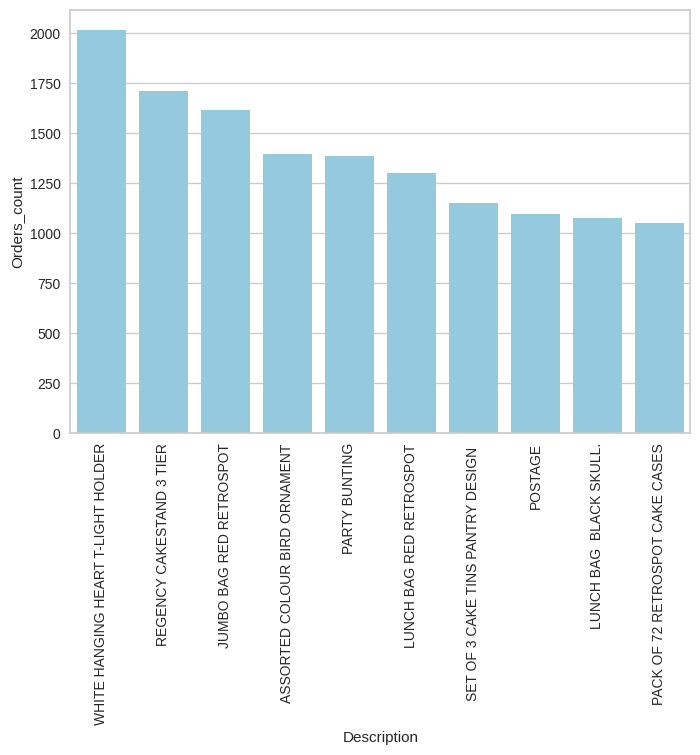

In [232]:
# top 100 seeling products
most_selling = customer_data['Description'].value_counts().head(10)
most_selling


sns.barplot(x=most_selling.index, y=most_selling.values,color = 'skyblue')
plt.ylabel('Orders_count')
plt.xticks(rotation=90)
plt.show()

In [233]:
# least selling product
least_selling = customer_data['Description'].value_counts().tail(20)
least_selling



,count
Description,
PINK SMALL GLASS CAKE STAND,1
RUBY GLASS CLUSTER NECKLACE,1
JET BLACK LAS VEGAS BRACELET ROUND,1
BLUE/GREEN SHELL NECKLACE W PENDANT,1
BLUE LEAVES AND BEADS PHONE CHARM,1
"GARLAND, MAGIC GARDEN 1.8M",1
PINK POLKADOT KIDS BAG,1
GLASS CAKE COVER AND PLATE,1
"LETTER ""O"" BLING KEY RING",1


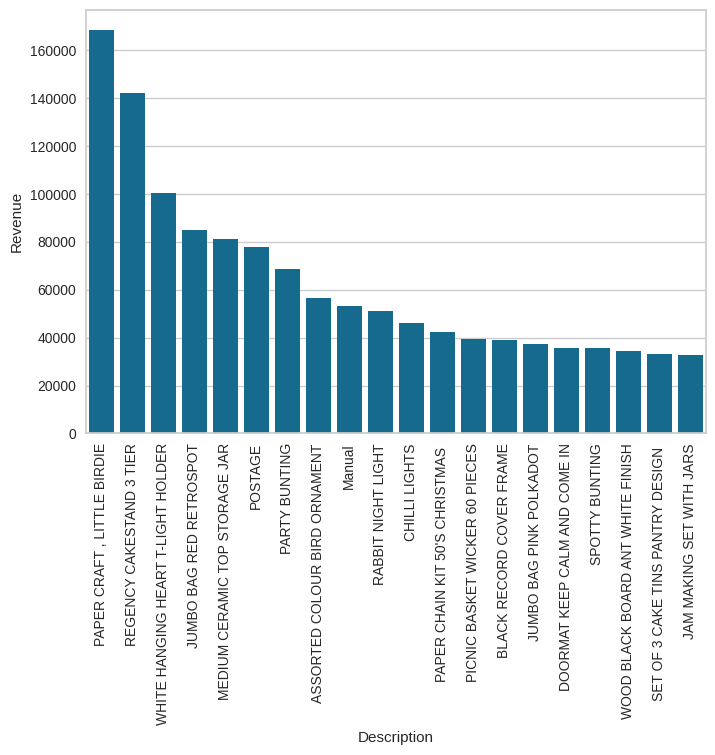

In [234]:
# 50 top product by revenue
most_revenue = customer_data.groupby('Description')['revenue'].sum().sort_values(ascending=False).head(20)
most_revenue

sns.barplot(x=most_revenue.index, y=most_revenue.values)
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show()

In [235]:
# 50  product with least revenue
least_revenue = customer_data.groupby('Description')['revenue'].sum().sort_values(ascending=True).head(20)
least_revenue

,revenue
Description,
PADS TO MATCH ALL CUSHIONS,0.003
HEN HOUSE W CHICK IN NEST,0.420
SET 12 COLOURING PENCILS DOILEY,0.650
VINTAGE BLUE TINSEL REEL,0.840
PINK CRYSTAL GUITAR PHONE CHARM,0.850
PURPLE FRANGIPANI HAIRCLIP,0.850
CAT WITH SUNGLASSES BLANK CARD,0.950
HAPPY BIRTHDAY CARD TEDDY/CAKE,0.950
60 GOLD AND SILVER FAIRY CAKE CASES,1.100


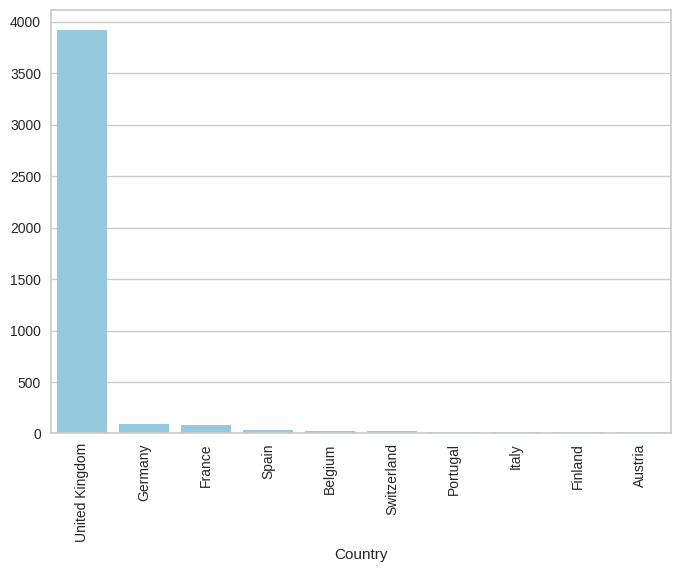

In [236]:
#countries with most number of customers
countrywise_customer = customer_data.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)
countrywise_customer


sns.barplot(x=countrywise_customer.index, y=countrywise_customer.values, color='skyblue')
plt.xticks(rotation=90)
plt.show()


* In this dataset more than 90 % of customers are from United kingdom

In [237]:
customer_data.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day,year,hour,minute,month,month_num,day_num,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,20.34


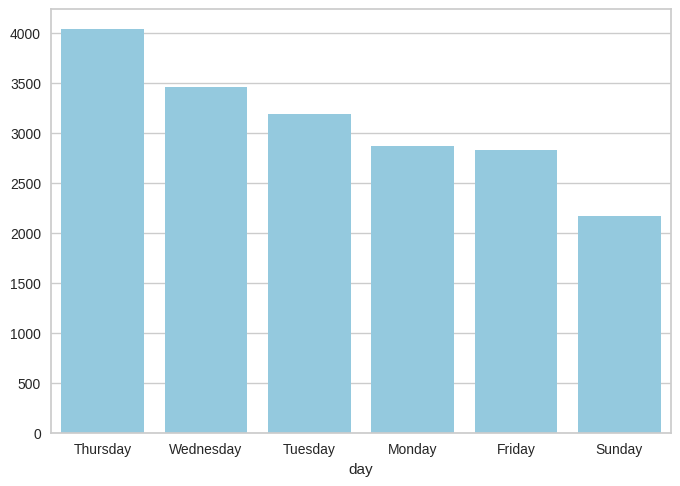

In [238]:
# day had most purchases
daywise_purchase = customer_data.groupby('day')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
daywise_purchase

sns.barplot(x=daywise_purchase.index, y=daywise_purchase.values, color='skyblue')
plt.show()

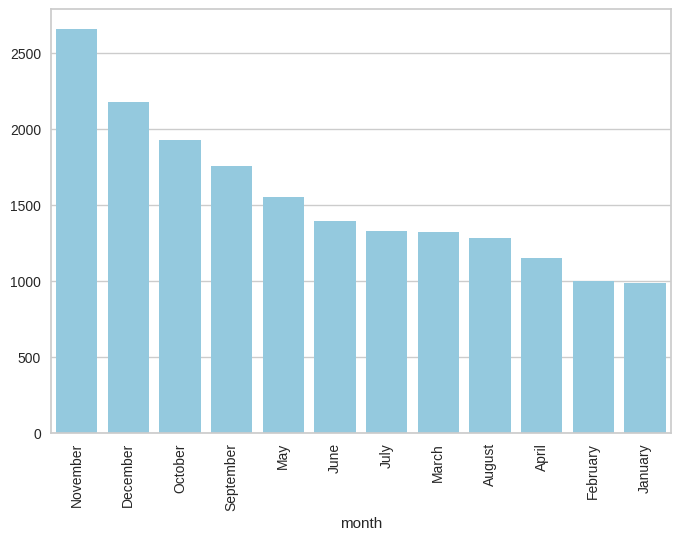

In [239]:

month_withmost_orders = customer_data.groupby('month')['InvoiceNo'].nunique().sort_values(ascending=False).head(12)
month_withmost_orders

sns.barplot(x=month_withmost_orders.index, y=month_withmost_orders.values, color='skyblue')
plt.xticks(rotation=90)
plt.show()

**From this bar chart we can say most of the customers are buying items in last quarter of the year**

* The UK academic year starts in September. This triggers massive shopping loops for clothing, electronics, stationery, and home goods as young adults move into university student housing.

* Halloween has exploded in popularity across the UK. It drives substantial consumer spending on decorations, costumes, themed food, party supplies, and confectionery.

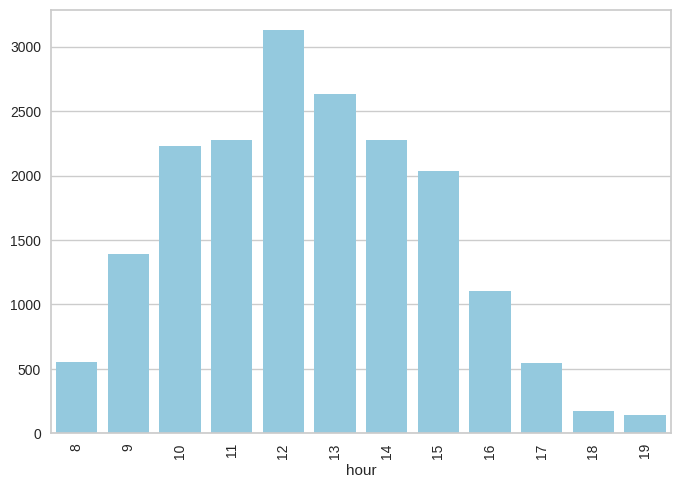

In [240]:
# at what time of the day most poeple placing thier orders
hourwise_purchase = customer_data.groupby('hour')['InvoiceNo'].nunique().sort_values(ascending=False).head(12)
hourwise_purchase

sns.barplot(x=hourwise_purchase.index, y=hourwise_purchase.values, color='skyblue')
plt.xticks(rotation=90)
plt.show()

This chart gives us a clear look into your customers' daily routines. In e-commerce and retail, this 11:00 AM to 2:00 PM peak is highly classic behavior known as "Lunch Break Shopping."

In [241]:
customer_data.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day,year,hour,minute,month,month_num,day_num,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,20.34


# **Distribution of Numerical features**





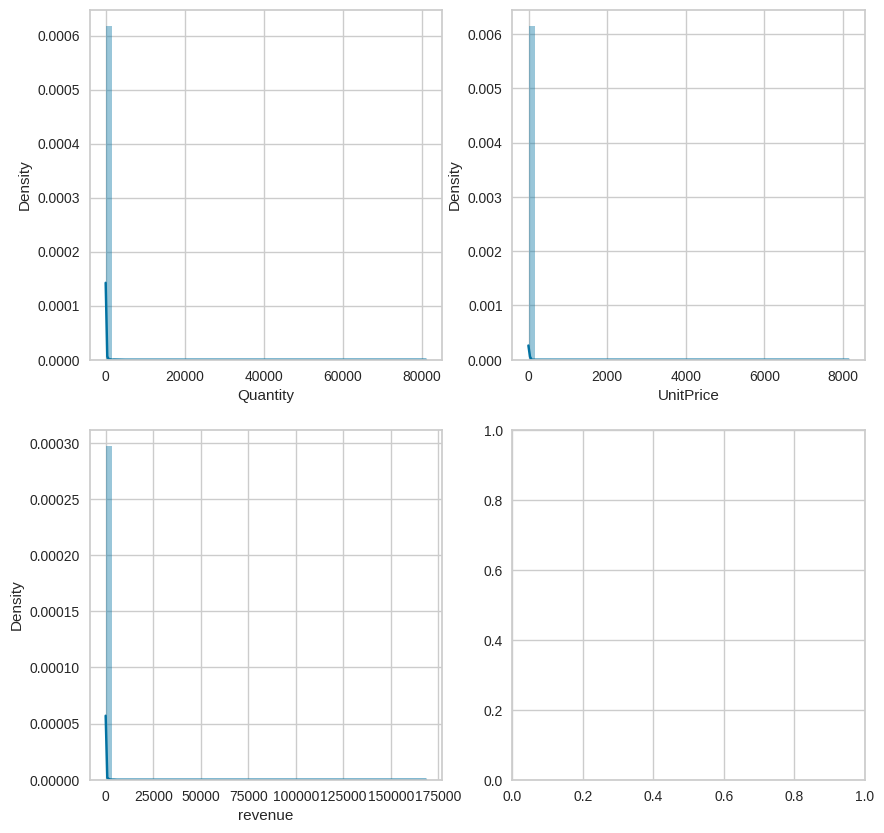

In [242]:
# showing distributing of numerical data like quantity, unit price, revenue in graph
fig, ax = plt.subplots(2,2, figsize=(10,10))
sns.distplot(customer_data['Quantity'], ax=ax[0,0])
sns.distplot(customer_data['UnitPrice'], ax=ax[0,1])
sns.distplot(customer_data['revenue'], ax=ax[1,0])
plt.show()


* from this  chart we can say our data is heavely skewed to the right

* we will use log transformation to make them less  skewed

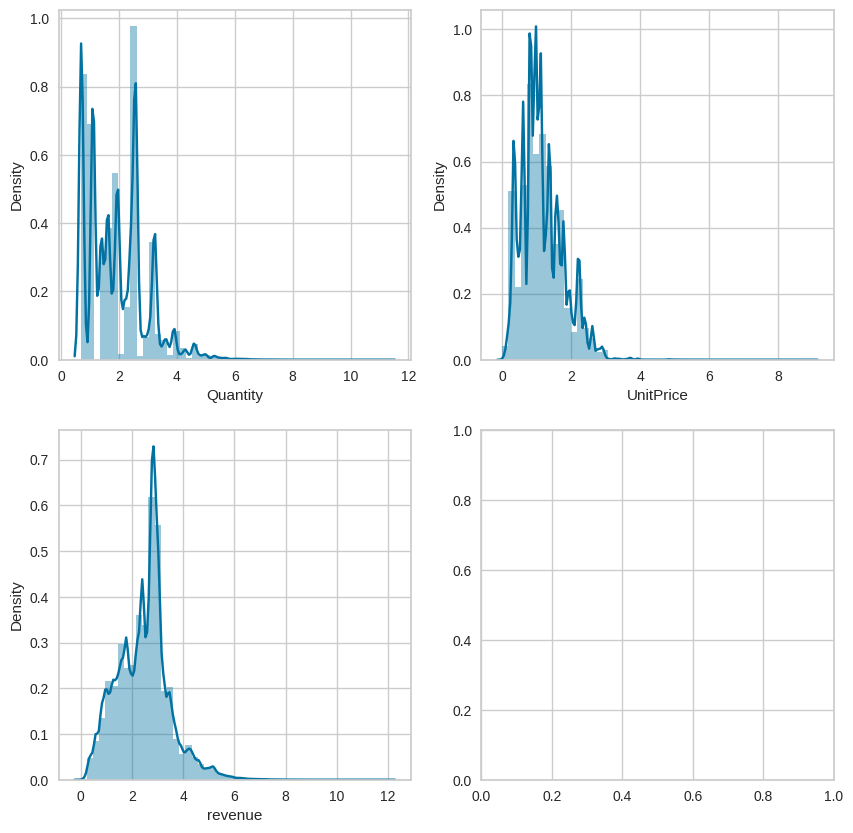

In [243]:
# apply log transofrmation on these three features
customer_data['Quantity'] = np.log1p(customer_data['Quantity'])
customer_data['UnitPrice'] = np.log1p(customer_data['UnitPrice'])
customer_data['revenue'] = np.log1p(customer_data['revenue'])

# represent data on bar graph after log transformation
fig, ax = plt.subplots(2,2, figsize=(10,10))
sns.distplot(customer_data['Quantity'], ax=ax[0,0])
sns.distplot(customer_data['UnitPrice'], ax=ax[0,1])
sns.distplot(customer_data['revenue'], ax=ax[1,0])
plt.show()

* after applying log transformation this is now looking somewhere close to normally distributed

# **Creating RFM Model (Recency , Frequency and Monetary)**
Recency , frequency, monetary value is a marketing analysis tool used to identify a organisations best customers by measuring and analyzing spendin habits

Factors of RFM models
1. Recency : How recently a customer has made a purchase
2. Frequency: How often customer make purchase
3. Monetary Value : How much money a customer spens on purchase



* Step1 : Assign Recency , Frequency, Monetry Values to each customer

* Step 2 : Divide customer list into tiered group grr each of dimensions(R,F and M)

* Step 3 : Select group of customers to whom specific type of communications will be sent based on RFM segment in which they appear

* Step 4: Crafting specific messaging that is tailored for each customer group


**Filtering data for UK only**


Reason : majority of data present in this dataset is for UK only

In [244]:
cust_data = customer_data[customer_data['Country'] =='United Kingdom']

cust_data.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day,year,hour,minute,month,month_num,day_num,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1.945910,2010-12-01 08:26:00,1.266948,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,2.791165
1,536365,71053,WHITE METAL LANTERN,1.945910,2010-12-01 08:26:00,1.479329,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,3.060583
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,2.197225,2010-12-01 08:26:00,1.321756,17850,United Kingdom,Wednesday,2010,8,26,December,12,1,3.135494


In [245]:
cust_data.shape

(349203, 16)

# **Calculating RFM/Feature Engineerign**



In [246]:
# set latest date to 2011-12-10 as last date of invoic was 2011-12-09
import datetime as dt
latest_date = dt.datetime(2011,12,10)

#creating rfm modeling score for each customer
rfm_score = cust_data.groupby('CustomerID').agg({'InvoiceDate': lambda x: (latest_date - x.max()).days,
                                        'InvoiceNo': lambda x: len(x),
                                        'revenue': lambda x: x.sum()})

In [247]:
rfm_score['InvoiceDate'] = rfm_score['InvoiceDate'].astype(int)


In [248]:
# changing columns name to Recency , Frequency, MonetaryValue
rfm_score.rename(columns={'InvoiceDate': 'Recency',
                         'InvoiceNo': 'Frequency',
                         'revenue': 'MonetaryValue'}, inplace=True)

In [249]:
rfm_score.reset_index()

,CustomerID,Recency,Frequency,MonetaryValue
0,12346,325,1,11.253955
1,12747,2,103,351.513396
2,12748,0,4412,7142.274710
3,12749,3,199,595.192559
4,12820,3,59,164.421493
...,...,...,...,...
3915,18280,277,10,29.342371
3916,18281,180,7,16.823758
3917,18282,7,12,32.267847
3918,18283,3,721,866.521170


In [250]:
rfm_score.head(5)

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346,325,1,11.253955
12747,2,103,351.513396
12748,0,4412,7142.274710
12749,3,199,595.192559
12820,3,59,164.421493


In [251]:
rfm_score.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3920 entries, 12346 to 18287
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Recency        3920 non-null   int64  
 1   Frequency      3920 non-null   int64  
 2   MonetaryValue  3920 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 122.5 KB


In [252]:
rfm_score.describe()

,Recency,Frequency,MonetaryValue
count,3920.000000,3920.000000,3920.000000
mean,91.742092,89.082398,213.055896
std,99.533485,214.034542,423.353782
min,0.000000,1.000000,1.558145
25%,17.000000,17.000000,44.765381
50%,50.000000,40.000000,100.112065
75%,142.000000,98.000000,239.216202
max,373.000000,7676.000000,11425.375121


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

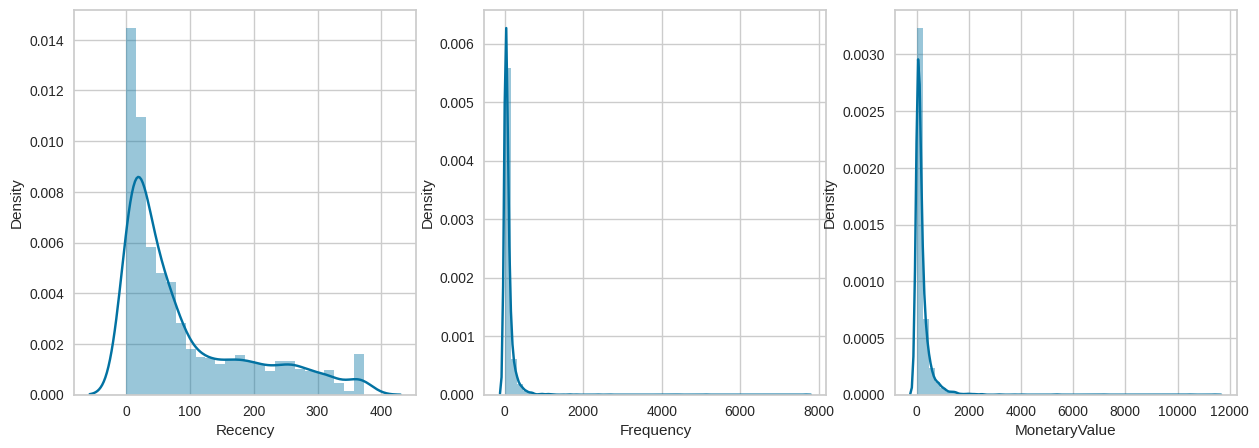

In [253]:
#plotting all Recency Frequency and Monetary Value on bargraph
fig, ax = plt.subplots(1,3, figsize=(15,5))
sns.distplot(rfm_score['Recency'], ax=ax[0])
sns.distplot(rfm_score['Frequency'], ax=ax[1])
sns.distplot(rfm_score['MonetaryValue'], ax=ax[2])
plt

In [254]:
# trating negative and 0 vaue to handel infinite number during log transfromation
def handel_negative(num):
  if num<=0:
    return 1
  else:
    return num


In [255]:
rfm_score['Recency'] = rfm_score['Recency'].apply(handel_negative)
rfm_score['Frequency'] = rfm_score['Frequency'].apply(handel_negative)


In [256]:
#apply log transformation to RFM values
log_rfm = rfm_score[['Recency', 'Frequency', 'MonetaryValue']].apply(np.log1p, axis=1).round(3)

In [257]:
log_rfm

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346,5.787,0.693,2.506
12747,1.099,4.644,5.865
12748,0.693,8.392,8.874
12749,1.386,5.298,6.391
12820,1.386,4.094,5.108
...,...,...,...
18280,5.628,2.398,3.413
18281,5.198,2.079,2.881
18282,2.079,2.565,3.505


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

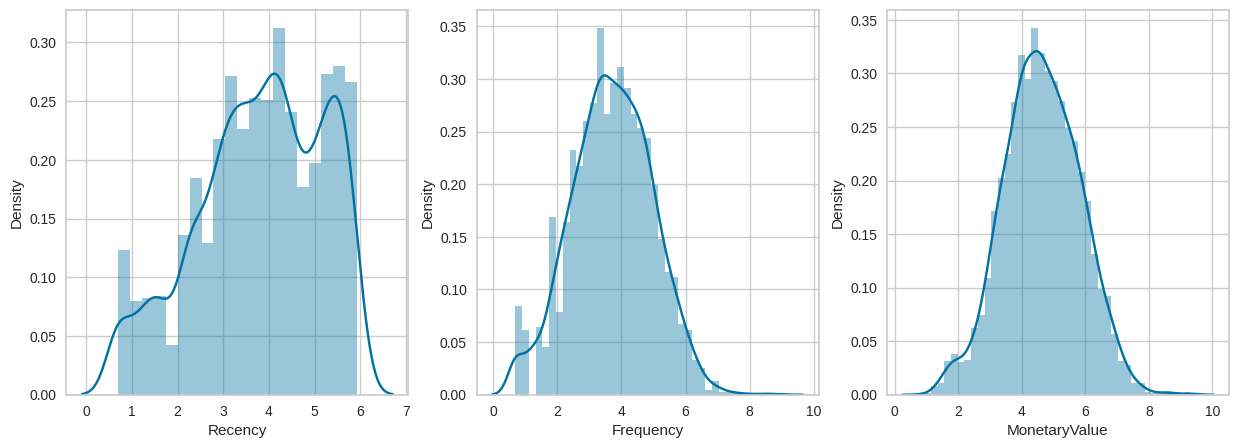

In [258]:
#plotting all Recency Frequency and Monetary Value on bargraph
fig, ax = plt.subplots(1,3, figsize=(15,5))
sns.distplot(log_rfm['Recency'], ax=ax[0])
sns.distplot(log_rfm['Frequency'], ax=ax[1])
sns.distplot(log_rfm['MonetaryValue'], ax=ax[2])
plt

**After applying log transformation on RFM the data which was heavely right skeweed is now looking normally distributed**

In [260]:
# applying log transformatio on original rfm_score dataframe
rfm_score['Recency_log']= rfm_score['Recency'].apply(math.log)
rfm_score['Frequency_log']= rfm_score['Frequency'].apply(math.log)
rfm_score['Monetary_log']= rfm_score['MonetaryValue'].apply(math.log)

In [261]:
rfm_score.head(5)

,Recency,Frequency,MonetaryValue,Recency_log,Frequency_log,Monetary_log
CustomerID,,,,,,
12346,325,1,11.253955,5.783825,0.000000,2.420720
12747,2,103,351.513396,0.693147,4.634729,5.862248
12748,1,4412,7142.274710,0.000000,8.392083,8.873787
12749,3,199,595.192559,1.098612,5.293305,6.388885
12820,3,59,164.421493,1.098612,4.077537,5.102433


In [262]:
rfm_score

,Recency,Frequency,MonetaryValue,Recency_log,Frequency_log,Monetary_log
CustomerID,,,,,,
12346,325,1,11.253955,5.783825,0.000000,2.420720
12747,2,103,351.513396,0.693147,4.634729,5.862248
12748,1,4412,7142.274710,0.000000,8.392083,8.873787
12749,3,199,595.192559,1.098612,5.293305,6.388885
12820,3,59,164.421493,1.098612,4.077537,5.102433
...,...,...,...,...,...,...
18280,277,10,29.342371,5.624018,2.302585,3.379033
18281,180,7,16.823758,5.192957,1.945910,2.822792
18282,7,12,32.267847,1.945910,2.484907,3.474071


In [263]:
from sklearn.preprocessing import StandardScaler, normalize
features = ['Monetary_log', 'Frequency_log', 'Monetary_log']
# scaling our data
x_feature =rfm_score[features].values
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_feature)


#K mean Clustring
**K-Means** Clustering is an **unsupervised** machine learning algorithm used to group similar data points together into distinct, non-overlapping groups called clusters.Since it is "unsupervised," it does not need predefined labels or targets. It uncovers hidden patterns in your data entirely on its own—making it the gold standard tool for Customer Segmentation workflows (like grouping your UK customer base by purchasing habits).

In [264]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score


In [277]:
def silhouette_analysis(n):
  for n_clusters in range(2,n):
    km = KMeans(n_clusters = n_clusters) #instantiate the kmean class
    pred = km.fit_predict(x_scaled) # .fit , .predict
    center = km.cluster_centers_


    score = silhouette_score(x_scaled, pred, metric = 'euclidean')
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))


In [278]:
silhouette_analysis(10)

For n_clusters = 2, silhouette score is 0.5379853316191239)
For n_clusters = 3, silhouette score is 0.5044228845580669)
For n_clusters = 4, silhouette score is 0.4819235085505705)
For n_clusters = 5, silhouette score is 0.4720544264530076)
For n_clusters = 6, silhouette score is 0.47386181522061804)
For n_clusters = 7, silhouette score is 0.4545718600448502)
For n_clusters = 8, silhouette score is 0.4376646771983156)
For n_clusters = 9, silhouette score is 0.4325216562169818)


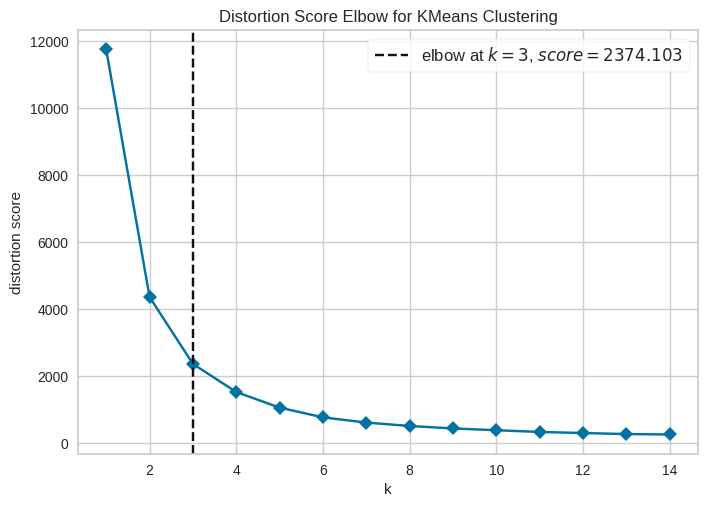

In [284]:
# elbow method to find out the best k
from yellowbrick.cluster import KElbowVisualizer
SSE = {}
for k in range(1,15):
  km = KMeans(n_clusters = k, init = 'k-means++', max_iter = 1000)
  km = km.fit(x_scaled)
  SSE[k] = km.inertia_

# plot the graph for SSE and number of clusters
visualizer = KElbowVisualizer(km, k=(1,15), metric='distortion', timings=False)
visualizer.fit(x_scaled)
visualizer.poof()
plt.show()

In [279]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3)
kmeans.fit(x_scaled)
y_km = kmeans.predict(x_scaled)

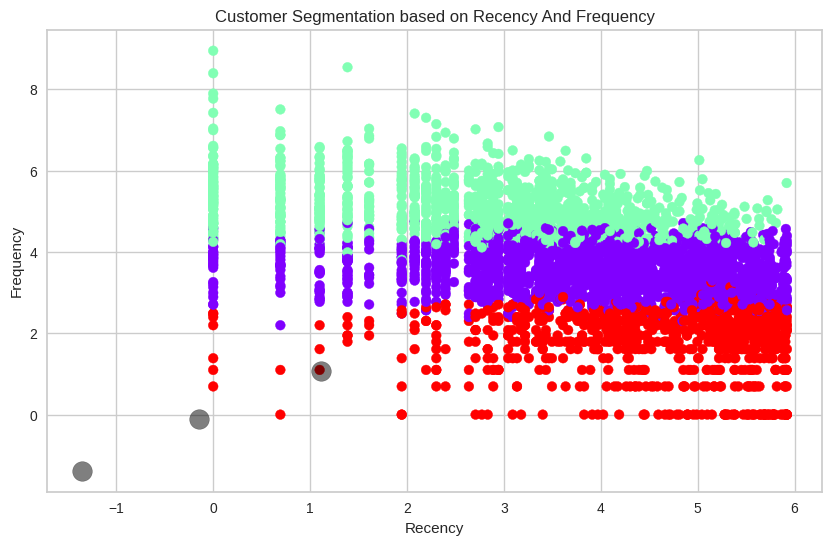

In [280]:
#plot the cluster on graph
plt.figure(figsize= (10,6))
plt.title('Customer Segmentation based on Recency And Frequency')
plt.scatter(rfm_score['Recency_log'], rfm_score['Frequency_log'], c=y_km, cmap='rainbow')
plt.xlabel('Recency')
plt.ylabel('Frequency')


# plot and annotate the centers
centers = kmeans.cluster_centers_
plt.scatter(x=centers[:,0], y=centers[:,1], c='black', s=200, alpha=0.5)

In [286]:
# split the rfm values into four quantiles
quantiles = rfm_score.quantile(q=[0.25,0.5,0.75])
quantiles = quantiles.to_dict()

In [287]:
# function to create R, F, M segments
def RScore(x,p,d):
  if x <= d[p][0.25]:
    return 1
  elif x <= d[p][0.5]:
    return 2
  elif x <= d[p][0.75]:
    return 3
  else:
    return 4

def FnMScore(x,p,d):
  if x <= d[p][0.25]:
    return 4
  elif x <= d[p][0.5]:
    return 3
  elif x <= d[p][0.75]:
    return 2
  else:
    return 1

In [290]:
# calculate RFM segment values for each record
rfm_score['R'] = rfm_score['Recency'].apply(RScore, args=('Recency', quantiles, ))
rfm_score['F'] = rfm_score['Frequency'].apply(FnMScore, args=('Frequency', quantiles, ))
rfm_score['M'] = rfm_score['MonetaryValue'].apply(FnMScore, args=('MonetaryValue', quantiles, ))
rfm_score.reset_index().head()

,CustomerID,Recency,Frequency,MonetaryValue,Recency_log,Frequency_log,Monetary_log,R,F,M
0,12346,325,1,11.253955,5.783825,0.000000,2.420720,4,4,4
1,12747,2,103,351.513396,0.693147,4.634729,5.862248,1,1,1
2,12748,1,4412,7142.274710,0.000000,8.392083,8.873787,1,1,1
3,12749,3,199,595.192559,1.098612,5.293305,6.388885,1,1,1
4,12820,3,59,164.421493,1.098612,4.077537,5.102433,1,2,2


In [292]:
# add RFM group column
rfm_score['RFMGroup'] = rfm_score['R'].map(str) + rfm_score['F'].map(str) + rfm_score['M'].map(str)

# calculate RFM score from RFM group column
rfm_score['RFMScore'] = rfm_score[['R', 'F', 'M']].sum(axis=1)
rfm_score.reset_index().head()

,CustomerID,Recency,Frequency,MonetaryValue,Recency_log,Frequency_log,Monetary_log,R,F,M,RFMGroup,RFMScore
0,12346,325,1,11.253955,5.783825,0.000000,2.420720,4,4,4,444,12
1,12747,2,103,351.513396,0.693147,4.634729,5.862248,1,1,1,111,3
2,12748,1,4412,7142.274710,0.000000,8.392083,8.873787,1,1,1,111,3
3,12749,3,199,595.192559,1.098612,5.293305,6.388885,1,1,1,111,3
4,12820,3,59,164.421493,1.098612,4.077537,5.102433,1,2,2,122,5


In [294]:
# find the clusters for the observations in the dataset
rfm_score['Cluster'] = kmeans.labels_
rfm_score.head()

,Recency,Frequency,MonetaryValue,Recency_log,Frequency_log,Monetary_log,R,F,M,RFMGroup,RFMScore,Cluster
CustomerID,,,,,,,,,,,,
12346,325,1,11.253955,5.783825,0.000000,2.420720,4,4,4,444,12,0
12747,2,103,351.513396,0.693147,4.634729,5.862248,1,1,1,111,3,2
12748,1,4412,7142.274710,0.000000,8.392083,8.873787,1,1,1,111,3,2
12749,3,199,595.192559,1.098612,5.293305,6.388885,1,1,1,111,3,2
12820,3,59,164.421493,1.098612,4.077537,5.102433,1,2,2,122,5,1


In [299]:
# Group by cluster label and calculate mean for numeric columns only
cluster_averages = rfm_score.groupby('Cluster').mean(numeric_only=True)
cluster_averages

,Recency,Frequency,MonetaryValue,Recency_log,Frequency_log,Monetary_log,R,F,M,RFMScore
Cluster,,,,,,,,,,
0,152.752351,8.656217,24.755859,4.584424,1.924178,3.050390,3.154650,3.960293,3.982236,11.097179
1,96.232831,41.550530,100.895276,3.925306,3.605192,4.522939,2.608040,2.611949,2.582356,7.802345
2,35.085324,227.390785,538.211874,2.746867,5.138485,6.042630,1.769625,1.191126,1.163823,4.124573


**Cluster 0:**

Recency: High

Frequency: Low
Monetary: Low

**Interpretation**: Customers in this cluster are likely to be 'At-Risk' or 'Lapsed' customers. They haven't made purchases recently, and when they did, they didn't do so very frequently and didn't spend much. These customers might have been one-time buyers or occasional shoppers. Engaging them with reactivation campaigns or exploring why they haven’t returned can be a strategic move.

**Cluster 1:**

Recency: Very Low

Frequency: Very High

Monetary: Very High

**Interpretation**: This cluster represents your 'Champions' or 'Loyal' customers. They shop frequently, recently, and spend the most. They are the most valuable segment, likely to respond positively to new offers, up-sell and cross-sell opportunities. Maintaining their high engagement level is crucial, and they can also be targeted for feedback or as brand ambassadors.

**Cluster 2:**

Recency: Moderate

Frequency: Moderate

Monetary: Moderate

**Interpretation**: Customers in this cluster can be seen as 'Potential Loyalists' or 'Promising' customers. They have a balanced score in all three RFM metrics. These customers have the potential to become more valuable if properly engaged. Tailored marketing strategies, loyalty programs, and incentives to increase their purchase frequency and value can be effective.


**Overall Strategy:**
**Cluster 0 ('At-Risk'):** Focus on re-engagement strategies. Understand their needs and reasons for not returning. Offer incentives or feedback surveys to encourage them to revisit and make purchases.

**Cluster 1 ('Champions'):** Prioritize maintaining their high level of engagement. Offer exclusive deals, loyalty programs, and early access to new products. They can also be engaged in referral programs.

**Cluster 2 ('Potential Loyalists'):** Encourage them to visit and buy more often. Personalized communication, recommending products based on past purchases, and loyalty rewards can be effective.